# BattProDeep: Dynamic Verification (Open-Source Model)

This educational notebook demonstrates the dynamic verification of the **BattProDeep** open-source battery aging model.

**Pipeline Overview:**
1. Initialize libraries, load validation profiles (PV-HESS and PV-PCR), and extract ground truth reference data from Naumann's cyclic aging experiment.
2. Inspect the C-rate and State of Charge (SOC) profiles.
3. Review the time-based vectorized simulation engine (Stochastic Particle Approach) used for predicting degradation.
4. Load pre-computed simulation results to visualize End-of-Life (EOL) confidence intervals and model prediction errors.

In [ ]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import gzip
from datetime import datetime
from joblib import Parallel, delayed
import joblib
from tqdm.auto import tqdm
from contextlib import contextmanager
from numba import njit
import tensorflow_probability as tfp
import scipy
from importlib import reload

# --- Path Setup for Open Source ---
myDir = os.getcwd()
sys.path.append(myDir)
path = Path(myDir)
parent = str(path.parent.absolute())
sys.path.extend([parent, os.path.join(parent, "scripts")])

from src.common.utils import *
from src.common.cycle_analyze_new import *
from src.common.matlab_interface import MatlabFileReader
from src.lfp.cycle_aging_current_modified_bootstrapped import CycleAging
from src.lfp.calendar_aging_current_modified_bootstrapped import CalendarAging

# --- 1. Initialization Parameters ---
directory_path = os.path.join(parent, "dataset/data_dynamic_validation")
initial_soc = {'PV_Batterie': 28.025, 'PV_PRL_Batterie': 60.025}
repeat_dict = {'PV_Batterie': 1368, 'PV_PRL_Batterie': 928}
temperature_dict = {'PV_Batterie': 40.8, 'PV_PRL_Batterie': 40.6}
battery_capacity = 3.0

# --- 2. Load & Align Input Profiles ---
current_profiles = {}
soc_profiles = {}

for filename in os.listdir(directory_path):
    if filename.endswith('.txt'):
        file_path = os.path.join(directory_path, filename)
        name = filename.replace('_Profil_Strom.txt', '')
        current_profile = pd.read_csv(file_path, delimiter='\t', header=None, usecols=[1])
        current_profiles[name] = current_profile
        soc_profiles[name] = calculate_soc_profile(current_profile, initial_soc=initial_soc[name], battery_capacity=battery_capacity)

def repeat_and_align_profiles(profiles_dict, repeat_dict, column_name, freq="min"):
    repeated_profiles = {}
    lengths = []
    for key in profiles_dict:
        base = np.asarray(profiles_dict[key]).reshape(-1)
        repeated = np.tile(base, repeat_dict[key])
        repeated_profiles[key] = repeated
        lengths.append(len(repeated))
    min_length = min(lengths)
    start_time = pd.Timestamp("2000-01-01")
    index = pd.date_range(start=start_time, periods=min_length, freq=freq)
    return {key: pd.DataFrame(arr[:min_length], index=index, columns=[column_name]) for key, arr in repeated_profiles.items()}

current_profiles_df = repeat_and_align_profiles(current_profiles, repeat_dict, column_name="Current")
final_profiles = {}
for key, df in current_profiles_df.items():
    temp_df = pd.DataFrame(temperature_dict[key], index=df.index, columns=["Temperature"])
    soc_df = pd.DataFrame(initial_soc[key] / 100.0, index=df.index, columns=["soc"])
    final_profiles[key] = pd.concat([df, temp_df, soc_df], axis=1)



print("✅ Environment setup, data aligned.")


✅ Environment setup, data aligned.


## Visualizing Validation Profiles
Before applying the aging models, we inspect the input sequences. The plot below illustrates the C-rate and the State of Charge (SOC) behavior over time for our two primary profiles: **PV-HESS** and **PV-PCR**.

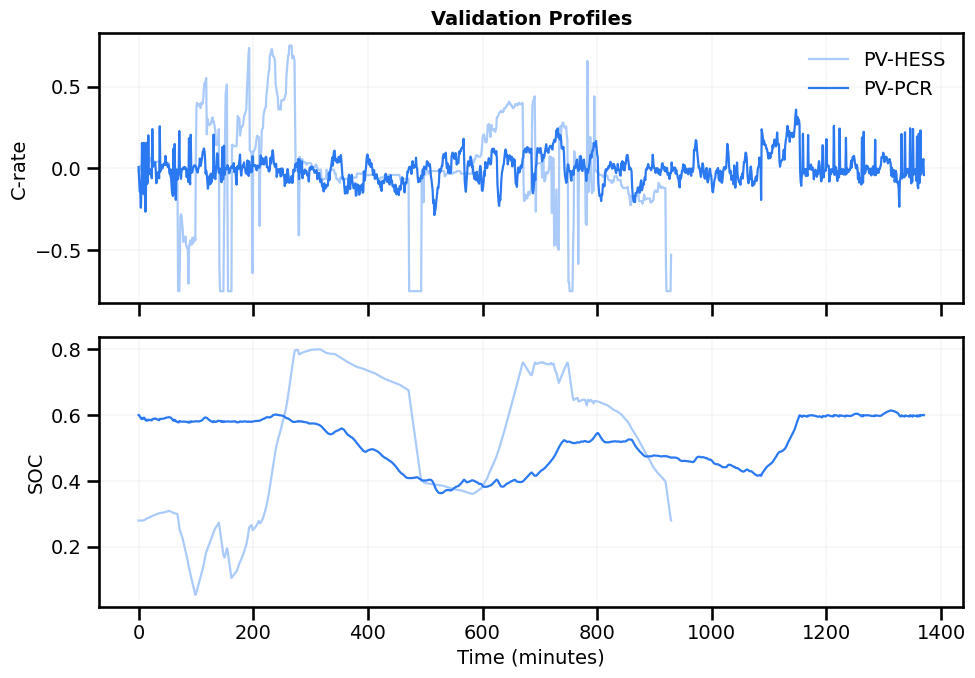

In [2]:
plt.rcParams.update({
    "font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14,
    "xtick.labelsize": 14, "ytick.labelsize": 14, "legend.fontsize": 14,
})

PROFILE_NAMES = {"PV_Batterie": "PV-HESS", "PV_PRL_Batterie": "PV-PCR"}
colors = ["#AACAF9", "#2B79F0"]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
ax_crate, ax_soc = axes

# C-rate subplot
for i, name in enumerate(PROFILE_NAMES.keys()):
    if name in current_profiles:
        x = current_profiles[name].index
        y = current_profiles[name][1] / battery_capacity
        ax_crate.plot(x, y, label=PROFILE_NAMES[name], color=colors[i], lw=1.6)

ax_crate.set_ylabel("C-rate")
ax_crate.set_title("Validation Profiles", fontweight="bold")
ax_crate.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)
ax_crate.legend(frameon=False)

# SoC subplot
for i, name in enumerate(PROFILE_NAMES.keys()):
    if name in soc_profiles:
        x = soc_profiles[name].index
        y = soc_profiles[name][1]
        ax_soc.plot(x, y, label=PROFILE_NAMES[name], color=colors[i], lw=1.6)

ax_soc.set_ylabel("SOC")
ax_soc.set_xlabel("Time (minutes)")
ax_soc.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)

plt.tight_layout()
plt.show()

## The Stochastic Looped Engine

Predicting battery degradation requires capturing path-dependent evolution over years. **BattProDeep** achieves this using a stochastic, looped approach.

### 1. The Looped Approach
Instead of processing a multi-year profile simultaneously, the simulation advances in **3-month time blocks**. Crucially, the battery's aged state including accumulated Full Equivalent Cycles (FEC), Virtual Time ($vt$), and State of Health (SoH)—is saved at the end of one block and handed over as the **initial condition** for the next.

### 2. Dual Probabilistic Aging Evaluation
Within each block, stress factors are extracted via half-cycle counting and fed into probabilistic Neural Networks:

* **Cycle Aging:** Inputs Delta FEC, Depth of Discharge (DoD), C-rates, and Temperature.
* **Calendar Aging:** Inputs resting SOC, Temperature, and dynamic Virtual Time ($vt$).

Both networks can predict  incremental capacity loss mean ($\mu$) and standard deviation ($\sigma$).

### 3. Stochastic Particles & Predictive Uncertainty
To model real-world variance, the simulation runs an ensemble of $M$ virtual particles (e.g., 100). Each particle is assigned a fixed, unique scalar ($\epsilon$). This $\epsilon$ is multiplied by the networks' predicted standard deviations ($\sigma$) to scatter the degradation trajectories.

---

### Interpreting the Band: "Model-Consistent Predictive Uncertainty"

As established in the methodology: *"Given the same usage profile, temperature history, and model uncertainty, these are plausible degradation outcomes."*

When viewing the **95% Confidence Interval (CI)** in our final plots:
* **2.5th percentile** $\rightarrow$ Optimistic battery trajectory
* **50th percentile** $\rightarrow$ Median battery trajectory
* **97.5th percentile** $\rightarrow$ Pessimistic battery trajectory

This states that **95% of model-consistent battery aging trajectories lie inside this band.**



In [ ]:

import src.lfp.cycle_aging_current_modified_bootstrapped as cycle_mod
import src.lfp.calendar_aging_current_modified_bootstrapped as cal_mod
reload(cycle_mod)
reload(cal_mod)
from src.lfp.cycle_aging_current_modified_bootstrapped import CycleAging
#from src.lfp.calendar_aging_current_vt import CalendarAging
from src.lfp.calendar_aging_current_modified_bootstrapped import CalendarAging
import src.common.utils as utils

reload(utils)

import importlib
import src.lfp.trajectory_uncertainty as tu
importlib.reload(tu)

from src.lfp.trajectory_uncertainty import (
    run_outer_loop_variants_timebased_vectorized,
    run_variant_timebased_vectorized,
    process_variant_vectorized,
    sample_uncertainty_particles,
    load_particle_results,
    close_particle_results,
)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

SyntaxError: invalid syntax (2048748662.py, line 17)

In [ ]:
paths = {
    "pickles_dir": r"..\results\dynamic\pickles",
    "run_base": r"..\results\dynamic",
}

# Optional sanity check
for name, df in final_profiles.items():
    print(name)
    print(df[["Current", "Temperature", "soc"]].head())
    print(df.index[0], df.index[-1], len(df))
    print(df[["Current", "Temperature", "soc"]].agg(["min", "max"]))
    print()

results = run_outer_loop_variants_timebased_vectorized(
    variants=final_profiles,
    paths=paths,
    C_nominal=3.0,       # Ah, matches battery_capacity = 3
    fec_window=1,
    years=1,
    n_jobs=1,            
    soc_max=1.0,
    soc_min=0.0,
    seed=42,
    M=99,
    n_boot=32,
    bootstrap_seed=42,
    avoid_eps_zeta_tail_alignment=True,
    epistemic_mode="sigma_e_reference_refsigma_independent", 
    calendar_epistemic_model_folder=r"..\trained_models\calendar\probabilistic\02-epistemic\condition_bootstrap_models_20260527_103926",
    cycle_epistemic_model_folder=r"..\trained_models\cycle\probabilistic\02-epistemic\trajectory_bootstrap_models_20260527_103926",
   
    epistemic_support_scale=0.5,
    disk_backed_streaming=True,
    disk_backed_root=r"..\results\dynamic\DevRuns\pickles\9_fec_with_input_feature",
   
    results_index_name="looped_particle_results_warmstart_32bootstrapped_sigma_e_reference_refsigma_independent_tail_0.5",
)

## Evaluation & Verification Metrics
To assess the model, we define two critical plotting functions:
- **`plot_soh_and_eol_fullwidth`**: Visualizes the predicted State of Health (SoH) over time, including the confidence interval bounds, and plots the End-of-Life (EOL) histograms against the true experimental data.
- **`plot_model_error_from_mean`**: Calculates and plots the relative percentage error between the mean model prediction and the true data.

In [13]:
# -------------------------------------------------
# 1. Define Plotting Logic (Both Functions)
# -------------------------------------------------
from numba import njit
import matplotlib.pyplot as plt
import numpy as np

@njit
def compute_soh(cycle_loss, calendar_loss, n_steps):
    cum_loss = 0.0
    soh = np.empty(n_steps)
    for t in range(n_steps):
        cum_loss += cycle_loss[t] + calendar_loss[t]
        soh[t] = max(0.0, 1.0 - cum_loss)
    return soh

# --- Plot 1: SOH and EOL Fullwidth ---
def plot_soh_and_eol_fullwidth(particle_results_dict, SOH_EOL=0.91, measured_dict=None, ci_level=0.95, bins=20, plot_points=1000):
    PROFILE_NAMES_PLOT = ["PV-HESS", "PV-PCR"]
    TRAJ_COLORS = ["#738499", "#2B79F0"]
    MEAN_COLORS = ["#D64113", "#862716"]
    TRUE_COLOR = "#4A4A4A"

    fig = plt.figure(figsize=(15, 7))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1.2], hspace=0.35)
    ax_top = fig.add_subplot(gs[0, :])
    hist_axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

    for idx, (key, results) in enumerate(particle_results_dict.items()):
        profile_name = PROFILE_NAMES_PLOT[idx] if idx < len(PROFILE_NAMES_PLOT) else key
        soc = results["soc"]
        n_particles, n_steps = soc.shape
        timestamps = results["timestamps"]

        days = (timestamps - timestamps[0]) / np.timedelta64(1, "D") if np.issubdtype(timestamps.dtype, np.datetime64) else np.array(timestamps, dtype=float)
        
        factor = max(1, n_steps // plot_points)
        plot_idx = np.arange(0, n_steps, factor)
        days_plot = days[plot_idx]

        soh_matrix = np.zeros((n_particles, len(plot_idx)))
        first_eol_days = np.full(n_particles, np.nan)

        for p in range(n_particles):
            cycle = results.get("cycle_loss", np.zeros((n_particles, n_steps)))[p][:n_steps]
            cal = results.get("calendar_loss", np.zeros((n_particles, n_steps)))[p][:n_steps]
            soh_full = compute_soh(cycle, cal, n_steps)
            soh_matrix[p] = soh_full[plot_idx]

            eol_idx = np.argmax(soh_full <= SOH_EOL)
            if soh_full[eol_idx] <= SOH_EOL:
                first_eol_days[p] = days[eol_idx]

        q = (1 - ci_level) / 2
        ax_top.fill_between(days_plot, np.quantile(soh_matrix, q, axis=0), np.quantile(soh_matrix, 1 - q, axis=0), color=TRAJ_COLORS[idx % 2], alpha=0.6, label=f"{profile_name} {int(ci_level*100)}% CI")
        ax_top.plot(days_plot, np.mean(soh_matrix, axis=0), color=MEAN_COLORS[idx % 2], lw=1.2, label=f"{profile_name} Mean")

        if measured_dict is not None and key in measured_dict:
            df_true = measured_dict[key]
            for j, col in enumerate(df_true.filter(like="y_").columns):
                true_soh = 1.0 - df_true[col].values / 100.0
                ax_top.scatter(df_true["Days Passed"].values, true_soh, color=TRUE_COLOR, s=50, alpha=0.75, zorder=10, label="True data" if (idx == 0 and j == 0) else None)

        valid_eol = first_eol_days[~np.isnan(first_eol_days)]
        ax_h = hist_axes[idx % 2]
        ax_h.hist(valid_eol, bins=bins, color=TRAJ_COLORS[idx % 2], alpha=0.7)
        ax_h.axvline(np.mean(valid_eol), color=MEAN_COLORS[idx % 2], lw=1, label="Mean")
        ax_h.set_title(profile_name)
        ax_h.set_xlabel("EOL time (days)")
        ax_h.set_ylabel("Count")
        ax_h.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        ax_h.legend(frameon=False)

    ax_top.axhline(SOH_EOL, color="#444444", linestyle=":", lw=1.2, label=f"EOL threshold ({SOH_EOL*100:.0f}%)")
    ax_top.set_ylabel("State of Health (SoH)")
    ax_top.set_xlabel("Time (days)")
    ax_top.set_ylim(0.85, 1.005)
    ax_top.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax_top.legend(frameon=False, ncol=2)
    plt.show()



## 4. Final Validation Output
We conclude the dynamic verification by loading the pre-computed model outputs and executing both validation plots to compare against the Naumann dataset.

Generating Plot 1: SoH and EOL Fullwidth...


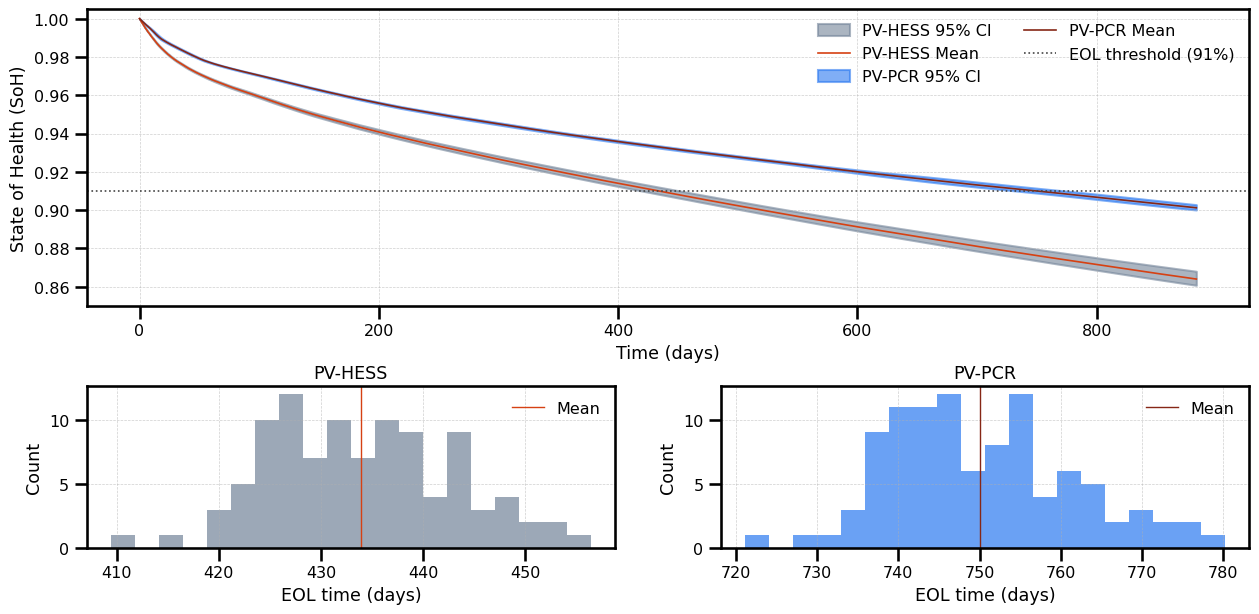

✅ Verification Plots generated successfully.


In [ ]:
# -------------------------------------------------
# 2. Load Supervisor's Pickles & Execute Plots
# -------------------------------------------------
# Ensure these paths point to where your provided pickles actually are
pkl_path_PV = r"..\results\dynamic\pickles\9_fec_with_input_feature\PV_Batterie_particle_results_20260302_202927.pkl.gz"
pkl_path_PRL = r"..\results\dynamic\pickles\9_fec_with_input_feature\PV_PRL_Batterie_particle_results_20260302_234647.pkl.gz"

try:
    with gzip.open(pkl_path_PV, "rb") as f:
        result_PV = pickle.load(f)
    with gzip.open(pkl_path_PRL, "rb") as f:
        result_PRL = pickle.load(f)

    combined_dict = {
        "PV_Batterie": result_PV,
        "PV_PRL_Batterie": result_PRL,
    }
    
    PROFILE_NAMES = ["PV-HESS", "PV-PCR"]

    print("Generating Plot 1: SoH and EOL Fullwidth...")
    # Plot 1: SoH and EOL
    plot_soh_and_eol_fullwidth(
        particle_results_dict=combined_dict,
        SOH_EOL=0.91,
        measured_dict=None,
        ci_level=0.95,
        bins=20
    )
    
   
   
    print("✅ Verification Plots generated successfully.")

except FileNotFoundError as e:
    print(f"❌ Could not find pickle file. Please verify the path. Details: {e}")
except Exception as e:
    print(f"❌ Error during loading or plotting: {e}")

## 5. Dynamic Figgener profiles

In [ ]:
# ===============================================================
# 📦 Setup environment and import BattProDeep dependencies
# ===============================================================

import os, sys, re, copy, pickle, scipy
from pathlib import Path
import tensorflow_probability as tfp
from joblib import Parallel, delayed
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from contextlib import contextmanager


# --- Configure paths ---
myDir = os.getcwd()
path = Path(myDir)
parent = str(path.parent.absolute())
sys.path += [myDir, parent, os.path.join(parent, "scripts")]

# --- Import BattProDeep modules ---
from src.common.utils import *
from src.common.cycle_analyze_new import *
from src.common.matlab_interface import MatlabFileReader



tfd, tfpl = tfp.distributions, tfp.layers

# ===============================================================
# 📁 Define project directories
# ===============================================================

directory_path = os.path.join(parent, "data_cycle")
model_path = os.path.join(parent, "trained_models")
model_path_cycle = os.path.join(model_path, "cycle")
model_path_calendar = os.path.join(model_path, "calendar")

fig_save_path = os.path.join(parent, "results")
field_dir = os.path.join(fig_save_path, "field")
devruns_base = os.path.join(field_dir, "DevRuns")
os.makedirs(devruns_base, exist_ok=True)

# ===============================================================
# 🧩 Helper functions
# ===============================================================

def _derive_module_name_from_path(p: str) -> str:
    """Extract module name, e.g., 'cpd_Module123.parquet' → 'Module123'."""
    base = os.path.basename(p)
    stem, _ = os.path.splitext(base)
    return stem[4:] if stem.startswith("cpd_") else stem

def _safe_module_name(s: str) -> str:
    """Sanitize module name for safe folder creation."""
    return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s)).strip('_')

def init_run_dirs(profile_path_or_module_name):
    """Create results/field/DevRuns/<Module>/{pickles,figures}."""
    raw = _derive_module_name_from_path(profile_path_or_module_name) if os.path.isfile(profile_path_or_module_name) else str(profile_path_or_module_name)
    module = _safe_module_name(raw)
    run_base = os.path.join(devruns_base, module)
    pickles_dir = os.path.join(run_base, "pickles")
    figures_dir = os.path.join(run_base, "figures")
    os.makedirs(pickles_dir, exist_ok=True)
    os.makedirs(figures_dir, exist_ok=True)
    return {
        "module": module,
        "run_base": run_base,
        "pickles_dir": pickles_dir,
        "figures_dir": figures_dir,
        "filename_loss_half_cycle": os.path.join(pickles_dir, "profile_loss_from_df.pkl"),
    }

# ===============================================================
# 🔧 Globals & configurations
# ===============================================================

paths = None
filename_loss_half_cycle = None
normalizer_path_cycle = os.path.join(model_path_cycle, 'normalizer')
normalizer_path_calendar = os.path.join(model_path_calendar, 'normalizer')

# MATLAB reader for cycle data
reader = MatlabFileReader(directory_path)

# Plot settings
pd.options.plotting.backend = "plotly"
template = "plotly_white"
px = 1 / plt.rcParams['figure.dpi']


In [ ]:
df_14_aligned = pd.read_pickle(r"..\dataset\df_14_aligned.pkl")

#normal data length 5.2 years,  extend as desired
df = df_14_aligned.copy()
#repeatthreetimes
dt = df.index[1] - df.index[0]

df_list = [df]

for i in range(1, 3):

    tmp = df.copy()

    tmp.index = tmp.index + i * (df.index[-1] - df.index[0] + dt)

    df_list.append(tmp)

df_rep = pd.concat(df_list)
df_rep = df_rep.iloc[:int(len(df) * 1.2)] #*1.2 for PMAPS

In [ ]:
variants = {
    "max_max_temp": df_rep.assign(
        Current=df_rep["I_in_A_cell_max"],
        Temperature=df_rep["T_cell_max"],
        soc=df_rep["SOC mit I-Verlust"],
    ),
    "min_min_temp": df_rep.assign(
        Current=df_rep["I_in_A_cell_min"],
        Temperature=df_rep["T_cell_min"],
        soc=df_rep["SOC mit I-Verlust"],
    ),
}

paths = init_run_dirs("figgener14")

results = run_outer_loop_variants_timebased_vectorized(
    variants=variants,
    paths=paths,
    C_nominal=3.0,
    fec_window=1,
    years=1,
    n_jobs=1, #change to 2 if both variatns run simulateously
    soc_max=1,
    soc_min=0.05,
    seed=42,
    M=401,
    n_boot=32, 
    bootstrap_seed=42,
    avoid_eps_zeta_tail_alignment=True,
    epistemic_mode="sigma_e_reference_refsigma_independent", 
    calendar_epistemic_model_folder=r"..\trained_models\calendar\probabilistic\02-epistemic\condition_bootstrap_models_20260527_103926",
    cycle_epistemic_model_folder=r"..\trained_models\cycle\probabilistic\02-epistemic\trajectory_bootstrap_models_20260527_103926",
    
    epistemic_support_scale=0.5,
    disk_backed_streaming=True,
    disk_backed_root=r"..\results\field\DevRuns\figgener14\pickles\9_fec_with_input_feature",
  
    results_index_name="looped_particle_results_warmstart_32bootstrapped_sigma_e_reference_refsigma_independent_tail_0.5_extend",
)


In [ ]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 1,
   "lines.linewidth":  1,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [ ]:
#colors
light_blue="#8FB6F5"
light_blue_max="#6E98E0"
"#5F86D6"
light_blue_min="#B7D1FA"
medium_blue="#2B79F0"
medium_blue_max="#1F5FCC"

medium_blue_min="#6AA4FF"
"#7FB2FF"
"#AACAF9"

dark_blue="#17467F"
dark_blue_max="#10345F"
dark_blue_min="#4A78B0"
grey_blue="#3b4f66"
grey_blue_max="#2C3E52"
grey_blue_min="#6A7D93"
"#C6D6E2"
"#B8C6D3"
"#8FA9C0"
"#A3B8CC"
"#738499"
navy="#1c2e4a"
navy_max="#142238"
navy_min="#3A5477"
"#738499"
orange="#E08214"
orange_max="#B5670F"
orange_min="#F5B86E"

In [ ]:
PROFILE_NAMES_FIG = ["Max Stress", "Min Stress"]
TRAJ_COLORS_FIG = [grey_blue_min, medium_blue]

MEAN_COLORS_FIG = ["#A03F2E", "#005C00"]
TRUE_COLOR = "#3FA34D"#"#4A4A4A"  

In [ ]:
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
def plot_soh_and_eol_trajectories_figgener_4(
    particle_results_dict,
    SOH_EOL=0.9,
    max_days=None,
    measured_timestamps=None,
    measured_values=None,
    ci_level=0.95,
    bins=30,
    save_path=None,
    plot_points=1200,
    time_unit="days",       # NEW: "days" (default, original behavior) or "years"
    days_per_year=365.25,   # NEW: only used when time_unit="years"
):
    assert time_unit in ("days", "years"), "time_unit must be 'days' or 'years'"

    def to_axis_unit(days_array):
        # NEW: only place any unit conversion happens; no-op when time_unit="days"
        return days_array / days_per_year if time_unit == "years" else days_array

    fig = plt.figure(figsize=(7, 3.4))
    gs = fig.add_gridspec(2, 1, height_ratios=[2.2, 1.2], hspace=0.3)
    ax_top = fig.add_subplot(gs[0, 0])
    ax_hist = fig.add_subplot(gs[1, 0])

    q = (1.0 - ci_level) / 2.0
    eol_payloads = []

    for idx, key in enumerate(particle_results_dict.keys()):
        results = particle_results_dict[key]
        profile_name = PROFILE_NAMES_FIG[idx]

        cycle_loss = results["cycle_loss"]
        calendar_loss = results["calendar_loss"]
        timestamps = results["timestamps"]

        n_particles = min(cycle_loss.shape[0], calendar_loss.shape[0])
        n_steps = min(cycle_loss.shape[1], calendar_loss.shape[1], len(timestamps))
        timestamps = timestamps[:n_steps]

        if np.issubdtype(timestamps.dtype, np.datetime64):
            days = np.asarray((timestamps - timestamps[0]) / np.timedelta64(1, "D"), dtype=float)
        else:
            days = np.asarray(timestamps, dtype=float)

        if max_days is not None:
            days = days[days <= max_days]
            n_steps = len(days)

        if n_steps < 1:
            raise ValueError(f"No timesteps available for profile {key!r}.")

        factor = max(1, n_steps // plot_points)
        plot_idx = np.arange(0, n_steps, factor, dtype=np.int64)
        if plot_idx[-1] != n_steps - 1:
            plot_idx = np.append(plot_idx, n_steps - 1)

        days_plot = days[plot_idx]
        axis_plot = to_axis_unit(days_plot)  # NEW: was days_plot everywhere below

        soh_matrix = np.empty((n_particles, len(plot_idx)), dtype=np.float64)
        first_eol_days = np.full(n_particles, np.nan, dtype=np.float64)

        for p in range(n_particles):
            soh_full = compute_soh(cycle_loss[p, :n_steps], calendar_loss[p, :n_steps], n_steps)
            soh_matrix[p] = soh_full[plot_idx]

            eol_idx = np.argmax(soh_full <= SOH_EOL)
            if soh_full[eol_idx] <= SOH_EOL:
                first_eol_days[p] = days[eol_idx]

            del soh_full

        final_soh = soh_matrix[:, -1]
        final_low, final_high = np.quantile(final_soh, [q, 1.0 - q])
        trajectory_mask = (final_soh >= final_low) & (final_soh <= final_high)
        selected_soh = soh_matrix[trajectory_mask]

        lower = selected_soh.min(axis=0)
        upper = selected_soh.max(axis=0)
        mean = selected_soh.mean(axis=0)

        # prints always stay in days, regardless of time_unit
        print(f"{profile_name}: retained {trajectory_mask.sum()}/{n_particles} SOH trajectories")
        print(f"{profile_name} final mean SOH: {mean[-1]:.4f}")
        if days_plot[0] <= 4500 <= days_plot[-1]:
            idx_4500 = np.argmin(np.abs(days_plot - 4500))
            print(f"{profile_name} mean SOH at day {days_plot[idx_4500]:.1f}: {mean[idx_4500]:.4f}")
        print(f"{profile_name} final SOH envelope: {lower[-1]:.4f}-{upper[-1]:.4f}")

        ax_top.plot(axis_plot, soh_matrix.T, color=TRAJ_COLORS_FIG[idx], alpha=0.15, lw=0.6, zorder=1)
        ax_top.fill_between(axis_plot, lower, upper, color=TRAJ_COLORS_FIG[idx], alpha=0.3, zorder=2,
                            label=f"{profile_name} {int(ci_level * 100)}% PI")
        ax_top.plot(axis_plot, mean, color=MEAN_COLORS_FIG[idx], lw=1.2, zorder=3, label=f"{profile_name} Mean")

        valid_eol = first_eol_days[np.isfinite(first_eol_days)]
        n_reached = len(valid_eol)
        n_not_reached = n_particles - n_reached

        if n_reached > 0:
            if n_not_reached:
                print(f"Warning: {profile_name}: {n_not_reached} trajectories did not reach EOL.")

            eol_low, eol_high = np.quantile(valid_eol, [q, 1.0 - q])
            selected_eol = valid_eol[(valid_eol >= eol_low) & (valid_eol <= eol_high)]

            # prints always stay in days
            print(f"{profile_name}: plotted {len(selected_eol)}/{n_reached} EOL dates")
            print(f"{profile_name} {ci_level:.0%} EOL range: {selected_eol.min():.1f}-{selected_eol.max():.1f} days")

            selected_eol_axis = to_axis_unit(selected_eol)  # NEW: was selected_eol directly
            eol_payloads.append({"name": profile_name, "values": selected_eol_axis, "color": TRAJ_COLORS_FIG[idx]})
        else:
            print(f"{profile_name}: no EOL crossings.")

    if eol_payloads:
        all_eol = np.concatenate([p["values"] for p in eol_payloads])
        eol_min, eol_max = all_eol.min(), all_eol.max()
        bin_edges = bins if eol_min == eol_max else np.linspace(eol_min, eol_max, bins + 1)

        for payload in eol_payloads:
            ax_hist.hist(payload["values"], bins=bin_edges, color=payload["color"], alpha=0.7, label="_nolegend_")

        ax_hist.axvline(eol_min, color=MEAN_COLORS_FIG[0], lw=1, linestyle="--", label="Earliest EOL")
        ax_hist.axvline(eol_max, color=MEAN_COLORS_FIG[1], lw=1, linestyle="--", label="Latest EOL")
        ax_hist.margins(x=0.05)
        if time_unit == "years":
            ax_hist.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # NEW: keep decimal resolution
    else:
        ax_hist.text(0.5, 0.5, "No EOL crossings", ha="center", va="center", transform=ax_hist.transAxes)

    ax_hist.set_xlabel(f"EOL expectance time ({time_unit}) for EOL threshold = {SOH_EOL*100:.0f}%", labelpad=1)  # NEW: was hardcoded "(days)"
    ax_hist.set_ylabel("Count")
    ax_hist.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax_hist.legend(frameon=False, ncol=2)

    if measured_timestamps is not None and measured_values is not None:
        true_timestamps = pd.to_datetime(measured_timestamps, format="%d.%m.%Y %H:%M").to_numpy()
        true_soh = np.asarray(measured_values, dtype=float) / 162.44
        reference_timestamps = next(iter(particle_results_dict.values()))["timestamps"]
        true_days = (true_timestamps - reference_timestamps[0]) / np.timedelta64(1, "D")

        if max_days is not None:
            measured_mask = true_days <= max_days
            true_days = true_days[measured_mask]
            true_soh = true_soh[measured_mask]

        true_axis = to_axis_unit(true_days)  # NEW: was true_days directly
        ax_top.scatter(true_axis, true_soh, color=TRUE_COLOR, s=15, marker="o", alpha=0.9,
                       zorder=7, label="SOH from field capacity tests")

    ax_top.axhline(SOH_EOL, color="#444444", linestyle=":", lw=1, label=f"EOL threshold ({SOH_EOL * 100:.0f}%)")

    target_date = np.datetime64("2020-09-20")
    reference_timestamps = next(iter(particle_results_dict.values()))["timestamps"]
    if np.issubdtype(reference_timestamps.dtype, np.datetime64):
        target_day = (target_date - reference_timestamps[0]) / np.timedelta64(1, "D")
        target_axis = to_axis_unit(np.array([target_day]))[0]  # NEW: was target_day directly
        ax_top.axvline(target_axis, color="#444444", linestyle="-.", lw=1, label="End of Monitored Data")

    ax_top.set_ylabel("State of Health (SOH)")
    ax_top.set_xlabel(f"Time ({time_unit})", labelpad=1)  # NEW: was hardcoded "(days)"
    ax_top.set_ylim(0.75, 1.005)

    max_days_xlim = max_days if max_days is not None else 4500
    xlim_axis = to_axis_unit(np.array([max_days_xlim]))[0]  # NEW: was hardcoded 4500
    ax_top.set_xlim(0, xlim_axis)
    if time_unit == "years":
        ax_top.set_xticks(np.arange(0, np.ceil(xlim_axis) + 1, 2))  # NEW: clean year ticks

    ax_top.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax_top.legend(frameon=False, ncol=2, loc="upper right")

    # # --- load image ---
    # img = mpimg.imread(r"..\results\Sonnen\DevRuns\figgener14\figures\system_icon.png")

    # # --- create inset axis (corner placement) ---
    # ax_inset = inset_axes(
    #     ax_top,
    #     width="15%",   # size relative to main plot
    #     height="40%",
    #     loc="lower left", #,"lower left",  # 'upper left', 'lower right', etc.
    #        borderpad=1,     )

    # ax_inset.imshow(img)
    # ax_inset.axis("off")

    if save_path:
        suffix = "" if time_unit == "days" else "_years"  # NEW: avoid overwriting the days-version file
        plt.savefig(f"{save_path}\\soh_eol_common_histogram_reduced{suffix}.pdf", dpi=400, bbox_inches="tight",
                    pad_inches=0.005, transparent=False)
        
    

    plt.show()

In [ ]:
result_file = Path(    r"..\results\Sonnen\DevRuns\figgener14\pickles\9_fec_with_input_feature\max_max_temp_particle_results_20260629_152612_062145.pkl.gz")
result_file_min = Path(    r"..\results\Sonnen\DevRuns\figgener14\pickles\9_fec_with_input_feature\min_min_temp_particle_results_20260701_060602_351281.pkl.gz")


max_result = load_particle_results(result_file)
min_result = load_particle_results(result_file_min)
combined_dict_9 = {"system_14_max":max_result, #sigma e
                   "system_14_min":min_result,}

for key, value in max_result.items():
    print(key, value.shape, value.dtype)

In [ ]:
timestamps_14 = ["02.06.2017  09:42", "19.02.2018  09:41", "09.05.2019  07:53"]
values_14 = [145.702428936944, 144.837147325556, 141.204634868056]
values_14_socrange = [145.702428936944/0.95, 144.837147325556/0.95, 141.204634868056/0.95]

In [ ]:
save_path = r"..\results\Sonnen\DevRuns\figgener14\figures"
plot_soh_and_eol_trajectories_figgener_4(
    particle_results_dict=combined_dict_9,
    SOH_EOL=0.8,
    max_days=None,
    measured_timestamps=timestamps_14,
    measured_values=values_14_socrange,
    ci_level=0.95,
    bins=80,
    save_path=save_path,
    plot_points=100000,
    time_unit="years", #or "days"
    days_per_year=365.25,
)